# 01. BART Fine-Tuning and Evaluation on CNN/DailyMail

This notebook fine-tunes `facebook/bart-base` for abstractive news summarization on CNN/DailyMail 3.0.0 and evaluates it against a Lead-3 extractive baseline.

Main components:

- Dataset loading, cleaning, and exploratory data analysis
- Token-length and truncation analysis for 512-token and 1024-token input limits
- Fine-tuning `facebook/bart-base` on a controlled training subset
- Automatic evaluation with ROUGE and BERTScore
- Article-length breakdown on the held-out test subset
- Exported prediction files for follow-up long-document and qualitative evaluation notebooks


## 1. Install Dependencies

Run this first in Colab. After installation, Colab may ask you to restart the runtime if package versions changed.

In [1]:
!pip -q install -U "transformers>=4.41" "datasets>=2.20" "evaluate>=0.4.2" accelerate rouge_score bert_score sentencepiece nltk pandas matplotlib seaborn

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 148.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 199.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 201.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 69.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency con

## 2. Imports and Configuration

The experiment uses the official CNN/DailyMail splits. Training and evaluation use fixed-size subsets for compute control, while the dataset length analysis can run on the full cleaned training split.

In [2]:
import os
import gc
import json
import math
import time
import random
import inspect
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import nltk
import evaluate
from datasets import load_dataset
from nltk.tokenize import sent_tokenize
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    set_seed,
)

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

# Project and storage
PROJECT_NAME = "bart_base_cnn_dm"
USE_GOOGLE_DRIVE = True
DRIVE_ROOT = "/content/drive/MyDrive/ML2Final/ml2_final_bart"
LOCAL_ROOT = "/content/ml2_final_bart"

# Dataset and model
MODEL_NAME = "facebook/bart-base"
DATASET_NAME = "cnn_dailymail"
DATASET_CONFIG = "3.0.0"

# Subset sizes. Training and evaluation use fixed-size subsets for compute control.
TRAIN_SIZE = 50_000
VAL_SIZE = 1_500
TEST_SIZE = 1_500

# Truncation analysis. None means use the full train split. Use 50000 if full analysis is too slow.
LENGTH_ANALYSIS_SIZE = None

# Tokenization and generation
MAX_SOURCE_LENGTH = 1024
MAX_TARGET_LENGTH = 128
NUM_BEAMS = 4
MIN_GENERATION_LENGTH = 30
NO_REPEAT_NGRAM_SIZE = 3

# Training hyperparameters
NUM_EPOCHS = 2
LEARNING_RATE = 3e-5
PER_DEVICE_TRAIN_BATCH_SIZE = 24
PER_DEVICE_EVAL_BATCH_SIZE = 24
GRADIENT_ACCUMULATION_STEPS = 1
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.03
LOGGING_STEPS = 50

# Metrics. BERTScore during training is slow, so keep it for final evaluation.
COMPUTE_BERTSCORE_DURING_TRAINING = False
BERTSCORE_MODEL_TYPE = "roberta-large"
BERTSCORE_BATCH_SIZE = 16

# Saving behavior. Trainer keeps only the best/latest single checkpoint by epoch.
SAVE_FINAL_MODEL_COPY = False

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

sns.set_theme(style="whitegrid")

Torch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Capability: (12, 0)


In [3]:
if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    OUTPUT_ROOT = DRIVE_ROOT
else:
    OUTPUT_ROOT = LOCAL_ROOT

RUN_NAME = f"{PROJECT_NAME}_train{TRAIN_SIZE}_src{MAX_SOURCE_LENGTH}_epochs{NUM_EPOCHS}"
OUTPUT_DIR = os.path.join(OUTPUT_ROOT, RUN_NAME)
CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")
RESULTS_DIR = os.path.join(OUTPUT_DIR, "results")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

config = {k: v for k, v in globals().items() if k.isupper() and isinstance(v, (str, int, float, bool, type(None)))}
with open(os.path.join(RESULTS_DIR, "run_config.json"), "w") as f:
    json.dump(config, f, indent=2)

print("Output directory:", OUTPUT_DIR)
print("Results directory:", RESULTS_DIR)

Mounted at /content/drive
Output directory: /content/drive/MyDrive/ml2_final_bart/bart_base_cnn_dm_train50000_src1024_epochs2
Results directory: /content/drive/MyDrive/ml2_final_bart/bart_base_cnn_dm_train50000_src1024_epochs2/results


## 3. Load and Clean CNN/DailyMail

CNN/DailyMail is a standard benchmark for news summarization. Each example contains a news article as input and a set of journalist-written highlights as the reference summary. The highlights are concise bullet-like summaries rather than fully natural multi-paragraph prose, which is a known limitation of the dataset.

In [4]:
try:
    raw_datasets = load_dataset(DATASET_NAME, DATASET_CONFIG)
except Exception as exc:
    print("Primary dataset load failed. Trying abisee/cnn_dailymail. Error was:", repr(exc))
    raw_datasets = load_dataset("abisee/cnn_dailymail", DATASET_CONFIG)

raw_datasets

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/15.6k [00:00<?, ?B/s]

Primary dataset load failed. Trying abisee/cnn_dailymail. Error was: HfUriError("Invalid HF URI 'hf://datasets/cnn_dailymail@96df5e686bee6baa90b8bee7c28b81fa3fa6223d/.huggingface.yaml'. Repository id must be 'namespace/name', got 'cnn_dailymail'.")


README.md:   0%|          | 0.00/15.6k [00:00<?, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

...

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})

In [5]:
def is_valid_example(example):
    article = example.get("article", "")
    highlights = example.get("highlights", "")
    return (
        isinstance(article, str)
        and isinstance(highlights, str)
        and len(article.strip()) >= 100
        and len(highlights.strip()) >= 20
    )

clean_datasets = raw_datasets.filter(is_valid_example)

print("Original sizes:", {split: len(raw_datasets[split]) for split in raw_datasets})
print("Cleaned sizes:", {split: len(clean_datasets[split]) for split in clean_datasets})

sample = clean_datasets["train"][0]
print("Fields:", sample.keys())
print("Article preview:\n", sample["article"][:800])
print("\nHighlights:\n", sample["highlights"])

Filter:   0%|          | 0/287113 [00:00<?, ? examples/s]

Filter:   0%|          | 0/13368 [00:00<?, ? examples/s]

Filter:   0%|          | 0/11490 [00:00<?, ? examples/s]

Original sizes: {'train': 287113, 'validation': 13368, 'test': 11490}
Cleaned sizes: {'train': 287111, 'validation': 13368, 'test': 11490}
Fields: dict_keys(['article', 'highlights', 'id'])
Article preview:
 LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," he told an Australian interviewer earlier this month. "I don't think I'll be particularly extravagant. "The things I like buying are things that cost about 10 pounds -- books and CDs and DVDs.

## 4. Dataset EDA before Modeling

Before modeling, we inspect the cleaned dataset size and text-length distribution. This gives context for the later token-level truncation analysis and explains why long-document handling matters for CNN/DailyMail.

,split,num_examples
0,train,287111
1,validation,13368
2,test,11490


article_words                                                      \
                   count    mean     std   min     25%    50%    75%     max   
split                                                                          
test             11490.0  683.51  348.40  55.0  419.00  613.0  876.0  1954.0   
train           287111.0  691.87  336.50  18.0  443.00  632.0  877.0  2347.0   
validation       13368.0  676.03  343.56  41.0  413.75  608.0  868.0  1917.0   

           summary_words         ... article_chars          summary_chars  \
                   count   mean  ...           75%      max         count   
split                            ...                                        
test             11490.0  55.01  ...       5076.75  11991.0       11490.0   
train           287111.0  51.57  ...        5117.0  15925.0      287111.0   
validation       13368.0  57.91  ...        5041.0  11412.0       13368.0   

                                                               
              mean     std   min    25%    50%    75%     max  
split                                                          
test        311.93  128.03  51.0  223.0  290.0  359.0  3410.0  
train       294.77  120.19  25.0  218.0  280.0  342.0  7388.0  
validation  328.03   146.3  52.0  229.0  299.0  386.0  8541.0  

[3 rows x 32 columns]

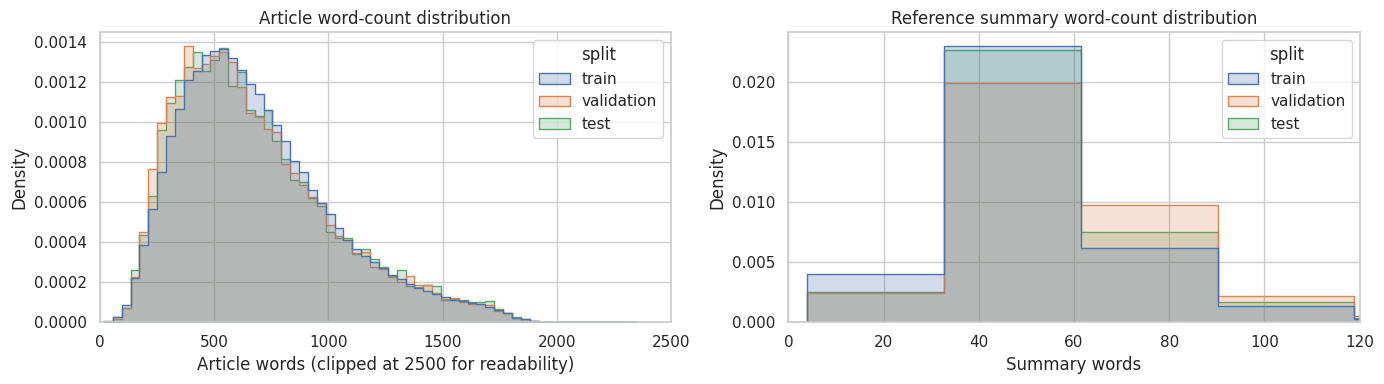

Saved EDA tables and plot to:
/content/drive/MyDrive/ml2_final_bart/bart_base_cnn_dm_train50000_src1024_epochs2/results/eda_split_sizes.csv
/content/drive/MyDrive/ml2_final_bart/bart_base_cnn_dm_train50000_src1024_epochs2/results/eda_text_length_summary_by_split.csv
/content/drive/MyDrive/ml2_final_bart/bart_base_cnn_dm_train50000_src1024_epochs2/results/eda_word_count_distributions.png


In [6]:
split_rows = []
for split in clean_datasets:
    split_rows.append({
        "split": split,
        "num_examples": len(clean_datasets[split]),
    })
split_size_df = pd.DataFrame(split_rows)
split_size_path = os.path.join(RESULTS_DIR, "eda_split_sizes.csv")
split_size_df.to_csv(split_size_path, index=False)
display(split_size_df)

# Word-count EDA uses whitespace tokens. BART-token EDA is computed in the next section.
def text_length_summary(dataset, split_name):
    articles = pd.Series(dataset["article"], dtype="string")
    highlights = pd.Series(dataset["highlights"], dtype="string")
    return pd.DataFrame({
        "split": split_name,
        "article_words": articles.str.split().str.len(),
        "summary_words": highlights.str.split().str.len(),
        "article_chars": articles.str.len(),
        "summary_chars": highlights.str.len(),
    })

eda_frames = [text_length_summary(clean_datasets[split], split) for split in clean_datasets]
eda_length_df = pd.concat(eda_frames, ignore_index=True)
eda_length_path = os.path.join(RESULTS_DIR, "eda_text_length_summary_by_split.csv")
eda_summary = eda_length_df.groupby("split")[["article_words", "summary_words", "article_chars", "summary_chars"]].describe().round(2)
eda_summary.to_csv(eda_length_path)
display(eda_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=eda_length_df, x="article_words", hue="split", bins=60, element="step", stat="density", common_norm=False, ax=axes[0])
axes[0].set_xlim(0, 2500)
axes[0].set_title("Article word-count distribution")
axes[0].set_xlabel("Article words (clipped at 2500 for readability)")

sns.histplot(data=eda_length_df, x="summary_words", hue="split", bins=50, element="step", stat="density", common_norm=False, ax=axes[1])
axes[1].set_xlim(0, 120)
axes[1].set_title("Reference summary word-count distribution")
axes[1].set_xlabel("Summary words")
plt.tight_layout()
eda_plot_path = os.path.join(RESULTS_DIR, "eda_word_count_distributions.png")
plt.savefig(eda_plot_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved EDA tables and plot to:")
print(split_size_path)
print(eda_length_path)
print(eda_plot_path)

## 5. Tokenizer and BART-Token Length Analysis

We measure how many articles exceed common transformer input limits. The 1024-token setting is the main training configuration, while 512 tokens is included as a smaller-context comparison point.

In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer max length:", tokenizer.model_max_length)
print("Pad token:", tokenizer.pad_token, tokenizer.pad_token_id)

config.json:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Tokenizer max length: 1000000000000000019884624838656
Pad token: <pad> 1


Truncation analysis examples: 287111


Counting BART tokens:   0%|          | 0/287111 [00:00<?, ? examples/s]

,metric,article_tokens,summary_tokens
0,mean,870.023231,67.691621
1,median,795.000000,64.000000
2,p75,1100.000000,78.000000
3,p90,1463.000000,100.000000
4,p95,1715.000000,116.000000
5,max,4677.000000,2428.000000


,threshold_tokens,num_examples,num_truncated,pct_truncated,avg_tokens_lost_when_truncated,median_tokens_lost_when_truncated
0,512,287111,228371,79.541014,483.557632,391.0
1,1024,287111,86235,30.035422,369.605926,280.0


,article_length_group,num_examples,pct_examples
0,513-1024,142136,49.505592
1,>1024,86235,30.035422
2,<=512,58740,20.458986


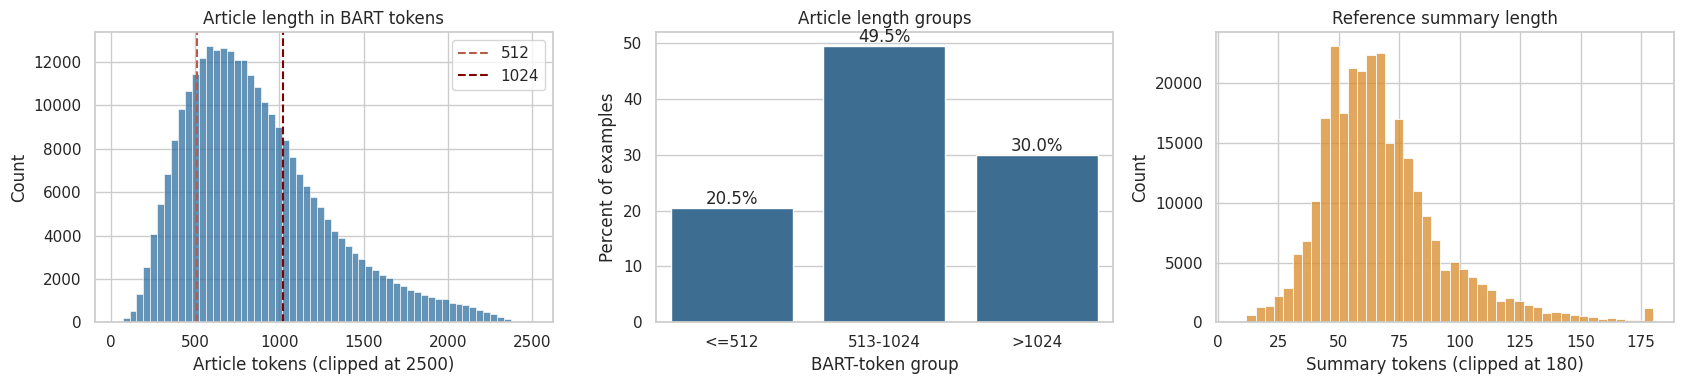

Saved token-level EDA plot to: /content/drive/MyDrive/ml2_final_bart/bart_base_cnn_dm_train50000_src1024_epochs2/results/eda_bart_token_length_analysis.png


In [8]:
def select_subset(dataset, n, seed=SEED):
    if n is None or n >= len(dataset):
        return dataset
    return dataset.shuffle(seed=seed).select(range(n))

analysis_ds = select_subset(clean_datasets["train"], LENGTH_ANALYSIS_SIZE, seed=SEED)
print("Truncation analysis examples:", len(analysis_ds))

def add_token_lengths(batch):
    article_ids = tokenizer(batch["article"], add_special_tokens=True, truncation=False)["input_ids"]
    summary_ids = tokenizer(batch["highlights"], add_special_tokens=True, truncation=False)["input_ids"]
    return {
        "article_tokens": [len(ids) for ids in article_ids],
        "summary_tokens": [len(ids) for ids in summary_ids],
    }

length_ds = analysis_ds.map(
    add_token_lengths,
    batched=True,
    batch_size=256,
    remove_columns=analysis_ds.column_names,
    desc="Counting BART tokens",
)

length_df = length_ds.to_pandas()

def truncation_summary(df, thresholds=(512, 1024)):
    rows = []
    for threshold in thresholds:
        over = df["article_tokens"] > threshold
        lost = (df.loc[over, "article_tokens"] - threshold).clip(lower=0)
        rows.append({
            "threshold_tokens": threshold,
            "num_examples": int(len(df)),
            "num_truncated": int(over.sum()),
            "pct_truncated": float(over.mean() * 100),
            "avg_tokens_lost_when_truncated": float(lost.mean()) if len(lost) else 0.0,
            "median_tokens_lost_when_truncated": float(lost.median()) if len(lost) else 0.0,
        })
    return pd.DataFrame(rows)

length_stats = pd.DataFrame({
    "metric": ["mean", "median", "p75", "p90", "p95", "max"],
    "article_tokens": [
        length_df["article_tokens"].mean(),
        length_df["article_tokens"].median(),
        length_df["article_tokens"].quantile(0.75),
        length_df["article_tokens"].quantile(0.90),
        length_df["article_tokens"].quantile(0.95),
        length_df["article_tokens"].max(),
    ],
    "summary_tokens": [
        length_df["summary_tokens"].mean(),
        length_df["summary_tokens"].median(),
        length_df["summary_tokens"].quantile(0.75),
        length_df["summary_tokens"].quantile(0.90),
        length_df["summary_tokens"].quantile(0.95),
        length_df["summary_tokens"].max(),
    ],
})

trunc_df = truncation_summary(length_df)
length_stats.to_csv(os.path.join(RESULTS_DIR, "token_length_stats.csv"), index=False)
trunc_df.to_csv(os.path.join(RESULTS_DIR, "truncation_summary.csv"), index=False)
length_df.to_csv(os.path.join(RESULTS_DIR, "article_token_lengths_raw.csv"), index=False)

display(length_stats)
display(trunc_df)

length_df["article_length_group"] = pd.cut(
    length_df["article_tokens"],
    bins=[0, 512, 1024, float("inf")],
    labels=["<=512", "513-1024", ">1024"],
    include_lowest=True,
)
length_group_df = (
    length_df["article_length_group"]
    .value_counts(normalize=False)
    .rename_axis("article_length_group")
    .reset_index(name="num_examples")
)
length_group_df["pct_examples"] = length_group_df["num_examples"] / len(length_df) * 100
length_group_df.to_csv(os.path.join(RESULTS_DIR, "eda_article_token_length_groups.csv"), index=False)
display(length_group_df)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
sns.histplot(length_df["article_tokens"].clip(upper=2500), bins=60, ax=axes[0], color="#2F6F9F")
axes[0].set_title("Article length in BART tokens")
axes[0].set_xlabel("Article tokens (clipped at 2500)")
axes[0].axvline(512, color="#B95B4C", linestyle="--", label="512")
axes[0].axvline(1024, color="#800000", linestyle="--", label="1024")
axes[0].legend()

sns.barplot(data=length_group_df, x="article_length_group", y="pct_examples", ax=axes[1], color="#2F6F9F")
axes[1].set_title("Article length groups")
axes[1].set_xlabel("BART-token group")
axes[1].set_ylabel("Percent of examples")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f%%")

sns.histplot(length_df["summary_tokens"].clip(upper=180), bins=45, ax=axes[2], color="#D88A28")
axes[2].set_title("Reference summary length")
axes[2].set_xlabel("Summary tokens (clipped at 180)")
plt.tight_layout()
token_eda_plot_path = os.path.join(RESULTS_DIR, "eda_bart_token_length_analysis.png")
plt.savefig(token_eda_plot_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved token-level EDA plot to:", token_eda_plot_path)

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(length_df["article_tokens"].clip(upper=2500), bins=80, ax=ax, color="#2F6F9F")
ax.axvline(512, color="#B95B4C", linestyle="--", linewidth=2, label="512")
ax.axvline(1024, color="#800000", linestyle="--", linewidth=2, label="1024")
ax.set_title("Article length in BART tokens")
ax.set_xlabel("Article tokens (clipped at 2500)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
standalone_hist_path = os.path.join(RESULTS_DIR, "article_token_histogram_512_1024.png")
plt.savefig(standalone_hist_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved standalone article-token histogram to:", standalone_hist_path)

## 6. Build Train, Validation, and Test Subsets

The project uses the official splits. The subset sizes are for compute control, not random re-splitting.

In [9]:
train_ds = select_subset(clean_datasets["train"], TRAIN_SIZE, seed=SEED)
val_ds = select_subset(clean_datasets["validation"], VAL_SIZE, seed=SEED)
test_ds = select_subset(clean_datasets["test"], TEST_SIZE, seed=SEED)

print("Train subset:", len(train_ds))
print("Validation subset:", len(val_ds))
print("Test subset:", len(test_ds))

Train subset: 50000
Validation subset: 1500
Test subset: 1500


## 7. Tokenize for Fine-Tuning

We use truncation because BART has a fixed context limit. We use dynamic padding through `DataCollatorForSeq2Seq`, so batches are padded only as much as necessary.

In [10]:
def preprocess_batch(batch):
    model_inputs = tokenizer(
        batch["article"],
        max_length=MAX_SOURCE_LENGTH,
        truncation=True,
    )
    labels = tokenizer(
        text_target=batch["highlights"],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train = train_ds.map(
    preprocess_batch,
    batched=True,
    remove_columns=train_ds.column_names,
    desc="Tokenizing train",
)
tokenized_val = val_ds.map(
    preprocess_batch,
    batched=True,
    remove_columns=val_ds.column_names,
    desc="Tokenizing validation",
)
tokenized_test = test_ds.map(
    preprocess_batch,
    batched=True,
    remove_columns=test_ds.column_names,
    desc="Tokenizing test",
)

print(tokenized_train)

Tokenizing train:   0%|          | 0/50000 [00:00<?, ? examples/s]

Tokenizing validation:   0%|          | 0/1500 [00:00<?, ? examples/s]

Tokenizing test:   0%|          | 0/1500 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 50000
})


## 8. Metrics

ROUGE is computed during training. BERTScore is computed in final evaluation to avoid slowing every validation pass.

In [11]:
rouge_metric = evaluate.load("rouge")
bertscore_metric = evaluate.load("bertscore")

def postprocess_text(preds, refs):
    preds = [pred.strip() for pred in preds]
    refs = [ref.strip() for ref in refs]
    # ROUGE-Lsum expects newline-separated sentences.
    preds = ["\n".join(sent_tokenize(pred)) for pred in preds]
    refs = ["\n".join(sent_tokenize(ref)) for ref in refs]
    return preds, refs

def compute_trainer_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]

    preds = np.asarray(preds)
    labels = np.asarray(labels)

    # Some Transformers versions pad generated predictions with -100.
    # The fast tokenizer cannot decode negative / invalid ids.
    preds = np.where(
        (preds < 0) | (preds >= tokenizer.vocab_size),
        tokenizer.pad_token_id,
        preds,
    ).astype(np.int64)

    labels = np.where(
        labels != -100,
        labels,
        tokenizer.pad_token_id,
    ).astype(np.int64)

    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds, decoded_labels = postprocess_text(decoded_preds, decoded_labels)

    rouge_result = rouge_metric.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True,
    )

    result = {key: value * 100 for key, value in rouge_result.items()}

    prediction_lens = [
        np.count_nonzero(pred != tokenizer.pad_token_id)
        for pred in preds
    ]
    result["gen_len"] = np.mean(prediction_lens)

    if COMPUTE_BERTSCORE_DURING_TRAINING:
        bs = bertscore_metric.compute(
            predictions=decoded_preds,
            references=decoded_labels,
            lang="en",
            model_type=BERTSCORE_MODEL_TYPE,
            batch_size=BERTSCORE_BATCH_SIZE,
            rescale_with_baseline=True,
        )
        result["bertscore_f1"] = float(np.mean(bs["f1"]) * 100)

    return {key: round(value, 4) for key, value in result.items()}

## 9. Fine-Tune `facebook/bart-base`

Mixed precision is selected automatically:

- BF16 on A100/H100/L4-class GPUs where supported
- FP16 fallback on older GPUs such as T4

Checkpoint saving is set to once per epoch with `save_total_limit=1`, so Drive does not fill with many model copies.

In [12]:
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

use_bf16 = torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8
use_fp16 = torch.cuda.is_available() and not use_bf16
print("Using bf16:", use_bf16)
print("Using fp16:", use_fp16)

training_kwargs = dict(
    output_dir=CHECKPOINT_DIR,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    num_train_epochs=NUM_EPOCHS,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LENGTH,
    generation_num_beams=NUM_BEAMS,
    logging_steps=LOGGING_STEPS,
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="rougeLsum",
    greater_is_better=True,
    report_to="none",
    bf16=use_bf16,
    fp16=use_fp16,
)

# Transformers renamed evaluation_strategy to eval_strategy in newer versions.
if "eval_strategy" in inspect.signature(Seq2SeqTrainingArguments.__init__).parameters:
    training_kwargs["eval_strategy"] = "epoch"
else:
    training_kwargs["evaluation_strategy"] = "epoch"

training_args = Seq2SeqTrainingArguments(**training_kwargs)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_trainer_metrics,
)

trainer

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Using bf16: True
Using fp16: False


In [13]:
train_start = time.time()
train_result = trainer.train()
train_runtime_minutes = (time.time() - train_start) / 60

trainer.save_state()
train_metrics = train_result.metrics
train_metrics["train_runtime_minutes_wall_clock"] = train_runtime_minutes

with open(os.path.join(RESULTS_DIR, "train_metrics.json"), "w") as f:
    json.dump(train_metrics, f, indent=2)

if SAVE_FINAL_MODEL_COPY:
    final_model_dir = os.path.join(OUTPUT_DIR, "final_model")
    trainer.save_model(final_model_dir)
    tokenizer.save_pretrained(final_model_dir)
    print("Saved final model copy to:", final_model_dir)

print("Training runtime minutes:", round(train_runtime_minutes, 2))
train_metrics

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
1,1.991372,1.718567,42.256300,19.590300,28.667100,39.290200,88.487300
2,1.855603,1.682202,42.760100,20.141800,29.325800,39.711700,83.421300


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Training runtime minutes: 13.51


{'train_runtime': 809.9762,
 'train_samples_per_second': 123.46,
 'train_steps_per_second': 5.146,
 'total_flos': 6.097234537046016e+16,
 'train_loss': 2.0166927903261387,
 'epoch': 2.0,
 'train_runtime_minutes_wall_clock': 13.506921422481536}

## 10. Baselines and Final Evaluation Helpers

In [14]:
def lead_n_summary(article, n=3):
    article = article.replace("\n", " ").strip()
    sentences = sent_tokenize(article)
    return " ".join(sentences[:n])

def normalize_for_metrics(preds, refs):
    return postprocess_text(preds, refs)

def compute_final_metrics(preds, refs, label):
    metric_preds, metric_refs = normalize_for_metrics(preds, refs)
    rouge_result = rouge_metric.compute(
        predictions=metric_preds,
        references=metric_refs,
        use_stemmer=True,
    )
    result = {"model": label}
    result.update({key: value * 100 for key, value in rouge_result.items()})

    bs = bertscore_metric.compute(
        predictions=preds,
        references=refs,
        lang="en",
        model_type=BERTSCORE_MODEL_TYPE,
        batch_size=BERTSCORE_BATCH_SIZE,
        rescale_with_baseline=True,
    )
    result["bertscore_f1"] = float(np.mean(bs["f1"]) * 100)
    result["num_examples"] = len(preds)
    return {key: (round(value, 4) if isinstance(value, float) else value) for key, value in result.items()}

def generate_with_model(model, tokenizer, articles, batch_size=PER_DEVICE_EVAL_BATCH_SIZE):
    model.eval()
    device = model.device
    outputs = []
    for start in range(0, len(articles), batch_size):
        batch_articles = articles[start:start + batch_size]
        inputs = tokenizer(
            batch_articles,
            max_length=MAX_SOURCE_LENGTH,
            truncation=True,
            padding=True,
            return_tensors="pt",
        ).to(device)
        with torch.no_grad():
            generated_ids = model.generate(
                **inputs,
                num_beams=NUM_BEAMS,
                max_length=MAX_TARGET_LENGTH,
                min_length=MIN_GENERATION_LENGTH,
                no_repeat_ngram_size=NO_REPEAT_NGRAM_SIZE,
                do_sample=False,
            )
        outputs.extend(tokenizer.batch_decode(generated_ids, skip_special_tokens=True))
    return outputs

## 11. Evaluate Lead-3 and Fine-Tuned BART-Base

In [15]:
test_articles = list(test_ds["article"])
test_refs = list(test_ds["highlights"])

lead3_preds = [lead_n_summary(article, n=3) for article in test_articles]
finetuned_preds = generate_with_model(trainer.model, tokenizer, test_articles)

metrics_rows = []
metrics_rows.append(compute_final_metrics(lead3_preds, test_refs, "Lead-3 extractive baseline"))
metrics_rows.append(compute_final_metrics(finetuned_preds, test_refs, "Fine-tuned facebook/bart-base"))

# Official Hugging Face self-reported reference values for facebook/bart-large-cnn.
metrics_rows.append({
    "model": "facebook/bart-large-cnn reported reference",
    "rouge1": 42.949,
    "rouge2": 20.815,
    "rougeL": 30.619,
    "rougeLsum": 40.038,
    "bertscore_f1": np.nan,
    "num_examples": "HF model card self-reported",
})

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(os.path.join(RESULTS_DIR, "final_metrics_summary.csv"), index=False)
display(metrics_df)

# Save predictions for follow-up analysis notebooks.
test_article_lengths = [len(ids) for ids in tokenizer(test_articles, add_special_tokens=True, truncation=False)["input_ids"]]
test_prediction_df = pd.DataFrame({
    "article": test_articles,
    "reference": test_refs,
    "article_tokens": test_article_lengths,
    "lead3_prediction": lead3_preds,
    "finetuned_bart_prediction": finetuned_preds,
})
test_prediction_df["length_group"] = pd.cut(
    test_prediction_df["article_tokens"],
    bins=[0, 512, 1024, float("inf")],
    labels=["<=512 tokens", "513-1024 tokens", ">1024 tokens"],
    include_lowest=True,
)
prediction_path = os.path.join(RESULTS_DIR, "test_predictions_with_lengths.csv")
test_prediction_df.to_csv(prediction_path, index=False)
print("Saved test predictions for downstream analysis:", prediction_path)
display(test_prediction_df[["article_tokens", "length_group", "reference", "lead3_prediction", "finetuned_bart_prediction"]].head())

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/bert_score/scorer.py:139: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable befor

,model,rouge1,rouge2,rougeL,rougeLsum,bertscore_f1,num_examples
0,Lead-3 extractive baseline,40.1828,17.5035,24.9322,36.4560,24.3851,1500
1,Fine-tuned facebook/bart-base,41.1159,18.4890,27.9197,38.0757,31.8394,1500
2,facebook/bart-large-cnn reported reference,42.9490,20.8150,30.6190,40.0380,NaN,HF model card self-reported


Saved test predictions for downstream analysis: /content/drive/MyDrive/ml2_final_bart/bart_base_cnn_dm_train50000_src1024_epochs2/results/test_predictions_with_lengths.csv


,article_tokens,length_group,reference,lead3_prediction,finetuned_bart_prediction
0,1647,>1024 tokens,CNN's Dr. Sanjay Gupta says we should legalize...,(CNN) I see signs of a revolution everywhere. ...,Dr. Rick Doblin: Medical marijuana revolution ...
1,558,513-1024 tokens,Child has amassed thousands of Twitter followe...,He looks barely teenage. But this child has am...,"Little boy from Memphis, Tennessee, poses with..."
2,642,513-1024 tokens,The presidential hopeful held a town hall meet...,New Jersey Governor Chris Christie wasn't look...,New Jersey Governor Chris Christie got into a ...
3,915,513-1024 tokens,Cassey Ho boasts over two million subscribers ...,YouTube star Cassey Ho has hit back at critics...,YouTube star Cassey Ho has hit back at critics...
4,538,513-1024 tokens,Aaron Cook was overlooked by Team GB for the L...,British taekwondo fighter Aaron Cook has confi...,Dorset-born Aaron Cook applied for citizenship...


## 12. Result Files

The important saved files from the main experiment are:

- `run_config.json`
- `train_metrics.json`
- `token_length_stats.csv`
- `truncation_summary.csv`
- `final_metrics_summary.csv`
- `test_predictions_with_lengths.csv`

Follow-up analyses are separated into:

- Notebook 02: dataset-wide article-length breakdown, long-article extensions, and reference coverage analysis
- Notebook 03: factual consistency and structured manual rubric workbook
- Notebook 04: recent-news demo


In [16]:
print("Results directory:", RESULTS_DIR)
for path in sorted(Path(RESULTS_DIR).glob("*")):
    print(path.name)

Results directory: /content/drive/MyDrive/ml2_final_bart/bart_base_cnn_dm_train50000_src1024_epochs2/results
eda_article_token_length_groups.csv
eda_bart_token_length_analysis.png
eda_split_sizes.csv
eda_text_length_summary_by_split.csv
eda_word_count_distributions.png
extension_long_context
final_metrics_summary.csv
run_config.json
test_predictions_with_lengths.csv
token_length_stats.csv
train_metrics.json
truncation_summary.csv
